# Setup Environment

In [1]:
# Import libraries

# Standard libraries
from pathlib import Path

# Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Models
import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, RocCurveDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.tree import plot_tree

# Saving and loading models
import joblib

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

NumPy version: 2.4.1
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2
Scikit-Learn version: 1.9.0


In [2]:
# Create image and model directories if they don't exist

eda_plots_dir             = Path("plots/EDA")
tuning_plots_dir          = Path("plots/Tuning")
evaluation_plots_dir      = Path("plots/Evaluation")
features_plots_dir        = Path("plots/Features")
models_dir                = Path("models")

eda_plots_dir.mkdir(parents=True, exist_ok=True)
tuning_plots_dir.mkdir(parents=True, exist_ok=True)
evaluation_plots_dir.mkdir(parents=True, exist_ok=True)
features_plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Data Loading and Exploratory Data Analysis (EDA)

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


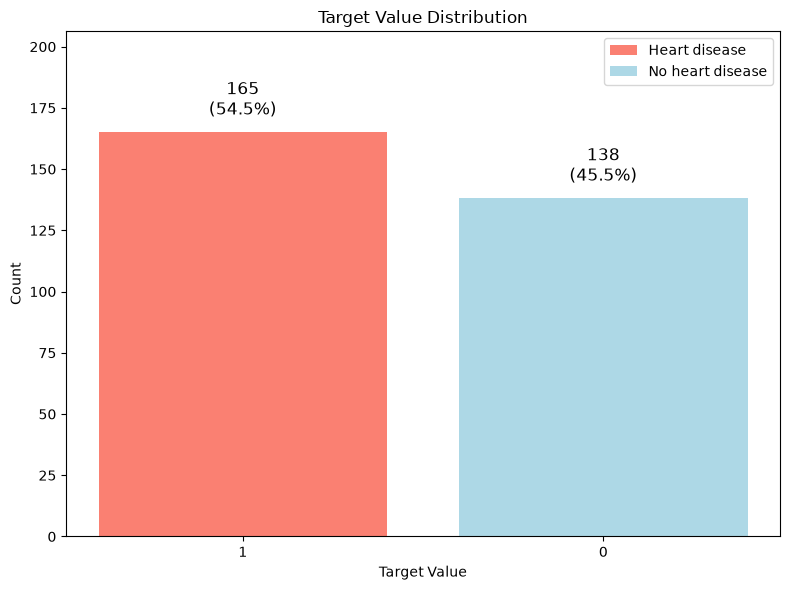

In [3]:
# Exploratory data analysis (EDA)

# Load the data
df = pd.read_csv('heart-disease.csv')

# Check for missing values, data types, and summary statistics
df.isnull().sum()
df.info()
df.describe()

# Plot the distribution of the target variable
counts = df.target.value_counts()

plt.figure(figsize=(8, 6))
plt.bar(0, counts[1], color="salmon", label="Heart disease")
plt.bar(1, counts[0], color="lightblue", label="No heart disease")

# add percentage annotations to the bars
for i, count in enumerate(counts):
    percentage = (count / len(df)) * 100
    plt.text(i, count + 5, f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=12)

plt.title("Target Value Distribution")
plt.xlabel("Target Value")
plt.ylabel("Count")
plt.xticks([0, 1], ["1", "0"])
plt.ylim(0, max(counts) * 1.25)
plt.legend()
plt.tight_layout()
plt.savefig(eda_plots_dir / "01_EDA_target_value_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

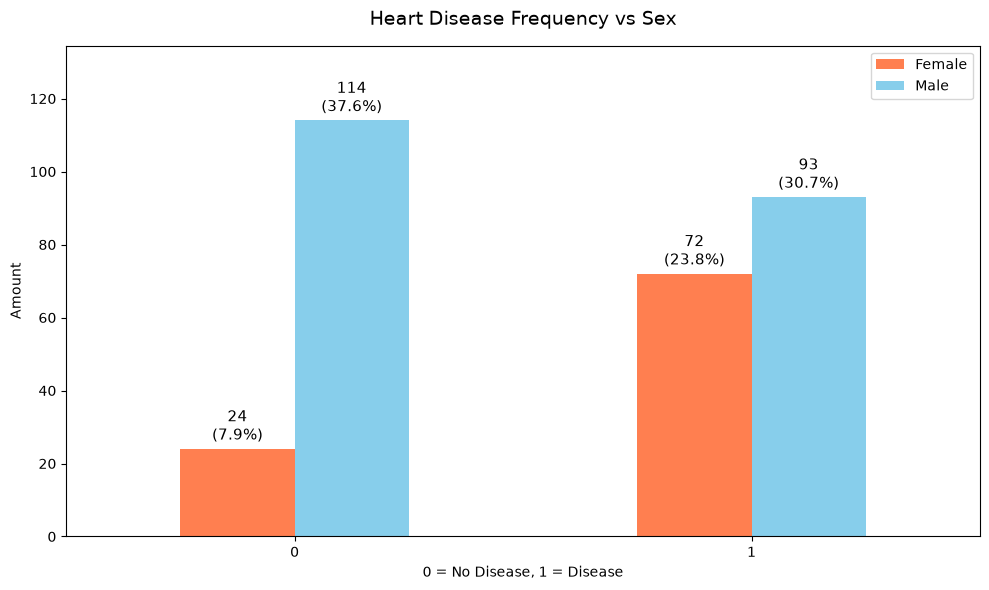

In [4]:
# Visualize the relationship between heart disease and sex

ax = pd.crosstab(df.target, df.sex).plot(
    kind="bar", figsize=(10, 6), color=["coral", "skyblue"]
)

# 2. Add percentage annotations using ax.containers
total_len = len(df)
for container in ax.containers:
    labels = [
        f"{int(v.get_height())}\n({(v.get_height() / total_len) * 100:.1f}%)"
        for v in container
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=11)

# 3. Formatting
plt.title("Heart Disease Frequency vs Sex", fontsize=14, pad=15)
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0)

# Optional: expand Y-axis slightly so labels don't get cut off at the top
plt.ylim(0, max(crosstab.values.max() for crosstab in [pd.crosstab(df.target, df.sex)]) * 1.18)

plt.tight_layout()
plt.savefig(
    eda_plots_dir / "02_EDA_heart_disease_vs_sex.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#####
# ~75% for women and ~45% for male
# ~55% of the dataset have heart disease -> baseline accuracy of 55% if we predict all patients have heart disease

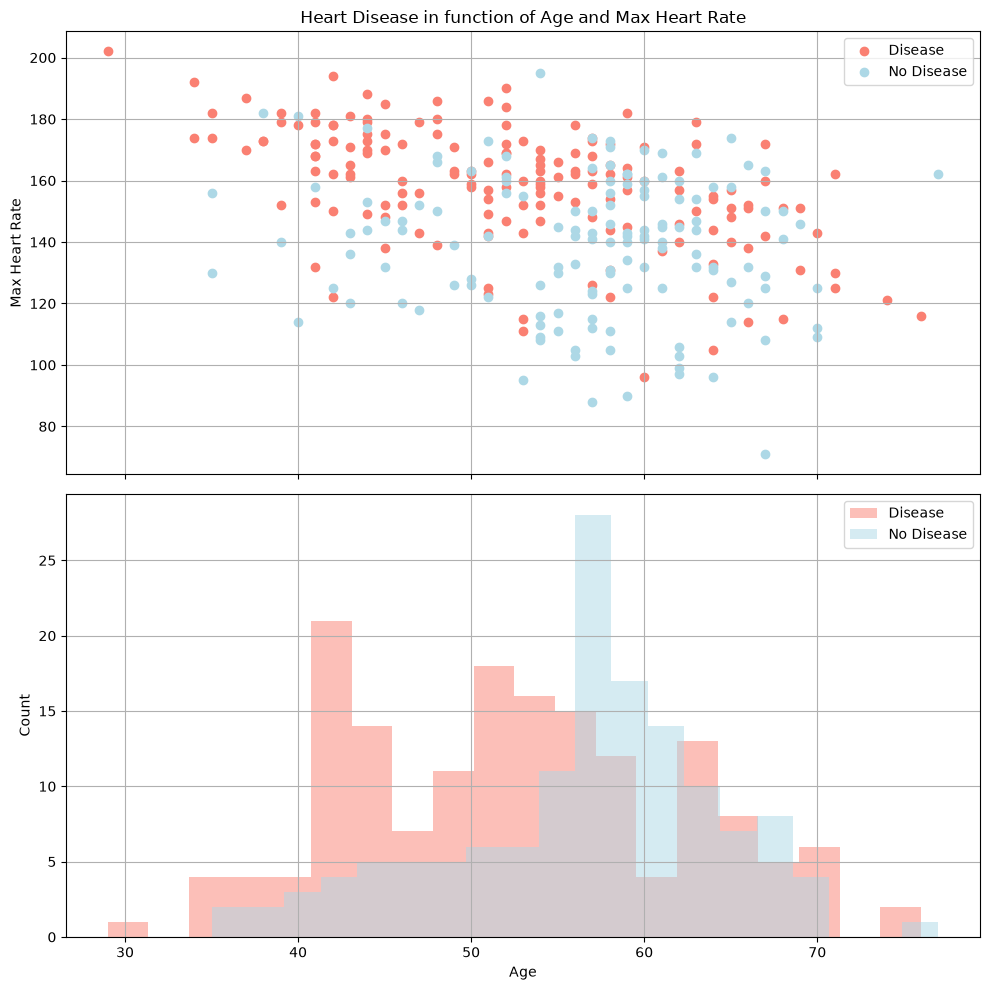

In [5]:
# Visualize the relationship between age and max heart rate, colored by target variable

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

# Scatter plot of age vs max heart rate, colored by target variable
ax0.scatter(df.age[df.target==1], df.thalach[df.target==1], c="salmon", label="Disease")
ax0.scatter(df.age[df.target==0], df.thalach[df.target==0], c="lightblue", label="No Disease")
ax0.set(title="Heart Disease in function of Age and Max Heart Rate", ylabel="Max Heart Rate")
ax0.legend()
ax0.grid(True)

# Histogram of age distribution, colored by target variable
ax1.hist(df.age[df.target==1], bins=20, alpha=0.5, color="salmon", label="Disease")
ax1.hist(df.age[df.target==0], bins=20, alpha=0.5, color="lightblue", label="No Disease")
ax1.set(xlabel="Age", ylabel="Count")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.savefig(eda_plots_dir / "03_EDA_heart_disease_vs_age_and_max_heart_rate.png", dpi=300, bbox_inches='tight')
plt.show()



# Younger -> higher max heart rate, older -> lower max heart rate
# Seems more heart disease in the younger population
# Normal distribution of age, slightly skewed to the right

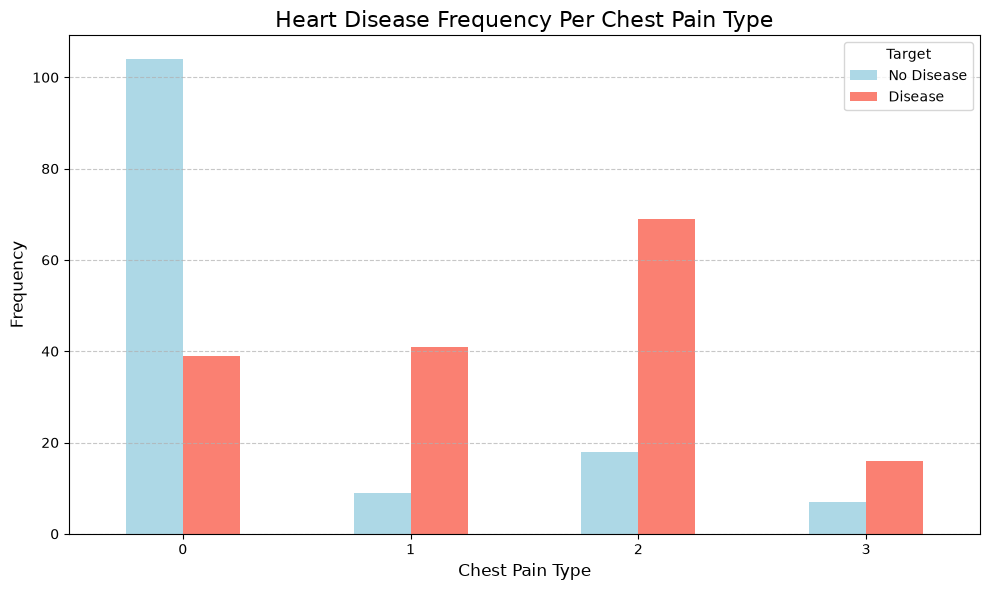

In [6]:
# Visualize the relationship between chest pain type and target variable

# Create a cross-tabulation of Chest Pain Type and Target
crosstab_result = pd.crosstab(df.cp, df.target)

# Plot the crosstab with a bar chart
ax = crosstab_result.plot(kind="bar", figsize=(10, 6), color=["lightblue", "salmon"])

# Add labels, title, and formatting for better readability
plt.title("Heart Disease Frequency Per Chest Pain Type", fontsize=16)
plt.xlabel("Chest Pain Type", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(["No Disease", "Disease"], title="Target")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add subtle gridlines
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.savefig(eda_plots_dir / "04_EDA_heart_disease_vs_chest_pain_type.png", dpi=300, bbox_inches='tight')
plt.show()

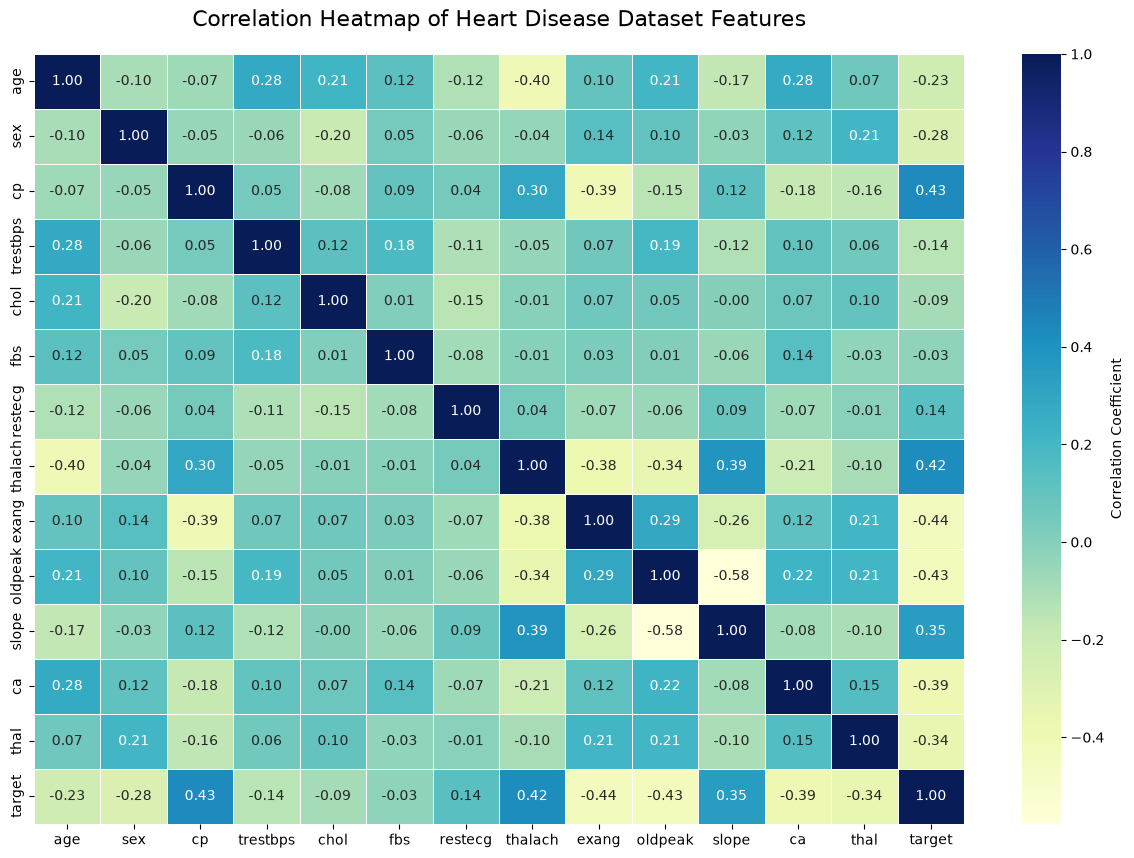

In [7]:
# Correlation between independent variables
# Calculate the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Create the heatmap with improved formatting
sns.heatmap(corr_matrix, 
            annot=True,          # Show the correlation coefficients
            linewidths=0.5,      # Add lines between cells
            fmt=".2f",           # Format to 2 decimal places
            cmap="YlGnBu",       # Use a professional color map
            cbar_kws={'label': 'Correlation Coefficient'}) # Add label to the color bar
plt.title("Correlation Heatmap of Heart Disease Dataset Features", fontsize=16, pad=20)
plt.savefig(eda_plots_dir / "05_EDA_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Modelling

In [8]:
# Data Splitting
X = df.drop("target", axis=1)
y = df["target"].to_numpy()         # Extract the target variable as a NumPy array

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
# Calculate the baseline accuracy for the candidate models

# Use Pipeline to ensure that distance-based models are scaled
models = {
    "KNN":                  Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
    "Logistic Regression":  Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1500))]),
    "SVM":                  Pipeline([("scaler", StandardScaler()), ("model", SVC())]),
    "Random Forest":        RandomForestClassifier(), # Note: Tree-based models do not require scaling
}

def evaluate_baseline_cv(models, X_train, y_train):
    """
    Evaluates baseline models using 5-Fold Cross-Validation on X_train.
    """
    np.random.seed(42)
    cv_scores = {}

    print("--- Baseline Models (5-Fold Cross-Validation on Train Set) ---")
    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
        cv_scores[name] = scores.mean()
        print(f"{name:<20} : {cv_scores[name]:.4f} (+/- {scores.std()*2:.4f})")

    best_model = max(cv_scores, key=cv_scores.get)
    print(f"\nBest Baseline Model: {best_model} with CV Score: {cv_scores[best_model]:.4f}")
    return cv_scores

baseline_cv_scores = evaluate_baseline_cv(models, X_train, y_train)

--- Baseline Models (5-Fold Cross-Validation on Train Set) ---
KNN                  : 0.8141 (+/- 0.0903)
Logistic Regression  : 0.8180 (+/- 0.0997)
SVM                  : 0.8184 (+/- 0.0520)
Random Forest        : 0.7935 (+/- 0.0354)

Best Baseline Model: SVM with CV Score: 0.8184


# Hyperparameter Tuning

In [10]:
# Tunning KNN Hyperparameters with GridSearchCV

# Define the pipeline and the parameter grid for KNN
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "model__n_neighbors": list(range(1, 31, 2)), 
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

# Create a GridSearchCV object for KNN
gs_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_param_grid,
    cv=5,                  
    scoring="f1", 
    verbose=2,
    n_jobs=-1
)

gs_knn.fit(X_train, y_train)

# Print the best results from GridSearchCV
print(f"KNN Best Accuracy Score: {gs_knn.best_score_:.4f}")
print("KNN Best Parameters:")
for param, value in gs_knn.best_params_.items():
    print(f"  {param}: {value}")

# Save the best KNN model to disk
joblib.dump(gs_knn.best_estimator_, models_dir / "best_knn_model.pkl")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
KNN Best Accuracy Score: 0.8597
KNN Best Parameters:
  model__n_neighbors: 5
  model__p: 1
  model__weights: uniform


['models\\best_knn_model.pkl']

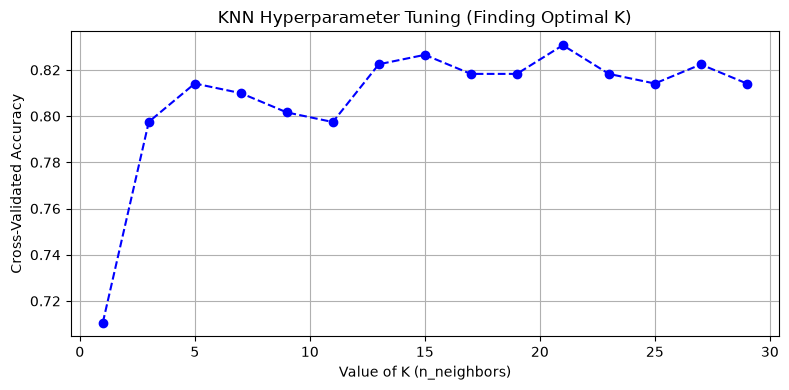

In [11]:
# Plotting the cross-validated accuracy scores for different n_neighbors values

# Extract the mean cross-validated accuracy scores for each n_neighbors value
scores = []
k_values = list(range(1, 31, 2))

for k in k_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)
    scores.append(cv_scores.mean())

# Plot the cross-validated accuracy scores against the n_neighbors values 
plt.figure(figsize=(8, 4))
plt.plot(k_values, scores, marker='o', linestyle='--', color='b')
plt.xlabel("Value of K (n_neighbors)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Hyperparameter Tuning (Finding Optimal K)")
plt.grid(True)
plt.tight_layout()
plt.savefig(tuning_plots_dir / "01_knn_hyperparameter_tuning.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Tuning SVM Hyperparameters with GridSearchCV

# Define the pipeline and the parameter grid for SVM
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(max_iter=10000, random_state=42))
])

svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf",],
    "model__gamma": ["scale", "auto", 0.01, 0.1]
}

# Create a GridSearchCV object for SVM
gs_svm = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,                 
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

gs_svm.fit(X_train, y_train)

# Print the best results from GridSearchCV
print(f"SVM Best 5-Fold CV Score: {gs_svm.best_score_:.4f}")
print("SVM Best Parameters Found:")
for param, value in gs_svm.best_params_.items():
    print(f"  {param}: {value}")

# Save the best SVM model to disk
joblib.dump(gs_svm.best_estimator_, models_dir / "best_svm_model.pkl")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
SVM Best 5-Fold CV Score: 0.8487
SVM Best Parameters Found:
  model__C: 10
  model__gamma: 0.01
  model__kernel: rbf


['models\\best_svm_model.pkl']

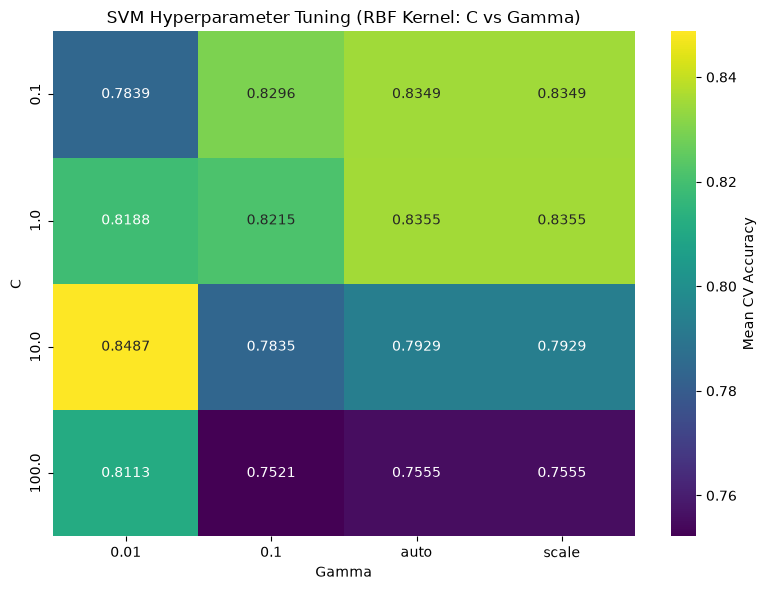

In [13]:
# Plotting the cross-validated accuracy scores for different combinations of C and gamma values for the RBF kernel

cv_results = pd.DataFrame(gs_svm.cv_results_)

# Filter the results for the RBF kernel
rbf_results = cv_results[cv_results['param_model__kernel'] == 'rbf']

# Transpose to Pivot Table 
# (C on the vertical axis, gamma on the horizontal axis, values are mean CV scores)
scores_matrix = rbf_results.pivot_table(
    index='param_model__C', 
    columns='param_model__gamma', 
    values='mean_test_score'
)

# Plot the heatma
plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, cmap="viridis", fmt=".4f", cbar_kws={'label': 'Mean CV Accuracy'})
plt.title("SVM Hyperparameter Tuning (RBF Kernel: C vs Gamma)")
plt.xlabel("Gamma")
plt.ylabel("C")
plt.tight_layout()
plt.savefig(tuning_plots_dir / "02_svm_hyperparameter_tuning_rbf_kernel.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Tuning Logistic Regression Hyperparameters with GridSearchCV

# Define the pipeline and the parameter grid for Logistic Regression
log_reg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="liblinear", max_iter=1500, random_state=42))
])

log_reg_grid = {
    "model__C": np.logspace(-4, 4, 20),
    "model__solver": ["lbfgs", "liblinear"]
}

# Create a GridSearchCV object for Logistic Regression
gs_log_reg = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=log_reg_grid,
    cv=5,
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

gs_log_reg.fit(X_train, y_train)

# Print the best results from GridSearchCV
print(f"Logistic Regression Best 5-Fold CV Score: {gs_log_reg.best_score_:.4f}")
print("Logistic Regression Best Parameters Found:")
for param, value in gs_log_reg.best_params_.items():
    print(f"  {param}: {value}")

# Save the best Logistic Regression model to disk
joblib.dump(gs_log_reg.best_estimator_, models_dir / "best_logistic_regression_model.pkl")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Logistic Regression Best 5-Fold CV Score: 0.8498
Logistic Regression Best Parameters Found:
  model__C: 0.004832930238571752
  model__solver: lbfgs


['models\\best_logistic_regression_model.pkl']

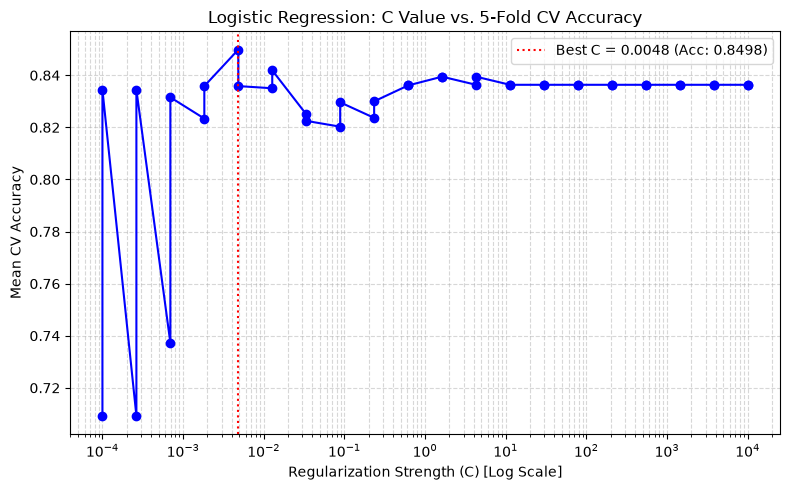

In [15]:
# Plotting the cross-validated accuracy scores for different C values in Logistic Regression

cv_results = pd.DataFrame(gs_log_reg.cv_results_)

plt.figure(figsize=(8, 5))
# Use a logarithmic scale for the x-axis to plot the relationship between C values and mean CV scores
plt.semilogx(cv_results["param_model__C"].astype(float), cv_results["mean_test_score"], marker='o', color='b')
plt.title("Logistic Regression: C Value vs. 5-Fold CV Accuracy")
plt.xlabel("Regularization Strength (C) [Log Scale]")
plt.ylabel("Mean CV Accuracy")
plt.grid(True, which="both", ls="--", alpha=0.5)

# Mark the best C value on the plot
best_c = gs_log_reg.best_params_["model__C"]
best_score = gs_log_reg.best_score_
plt.axvline(x=best_c, color='r', linestyle=':', label=f'Best C = {best_c:.4f} (Acc: {best_score:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig(tuning_plots_dir / "03_log_reg_hyperparameter_tuning.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Tuning Random Forest Hyperparameters with RandomizedSearchCV

# Define the hyperparameter search grid for Random Forest
rf_grid = {
    "n_estimators": np.arange(10, 1000, 50),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2)
}

# Create a RandomizedSearchCV object for Random Forest
np.random.seed(42)
rs_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_grid,  
    n_iter=20,                   
    cv=5,                  
    scoring="f1",
    verbose=2,
    n_jobs=-1,                  
    random_state=42
)

rs_rf.fit(X_train, y_train)

# Print the best results from RandomizedSearchCV
print(f"Random Forest Best 5-Fold CV Score: {rs_rf.best_score_:.4f}")
print("Random Forest Best Parameters Found:")
for param, value in rs_rf.best_params_.items():
    print(f"  {param}: {value}")

# Save the best Random Forest model to disk
joblib.dump(rs_rf.best_estimator_, models_dir / "best_random_forest_model.pkl")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest Best 5-Fold CV Score: 0.8418
Random Forest Best Parameters Found:
  n_estimators: 960
  min_samples_split: 4
  min_samples_leaf: 13
  max_depth: 3


['models\\best_random_forest_model.pkl']

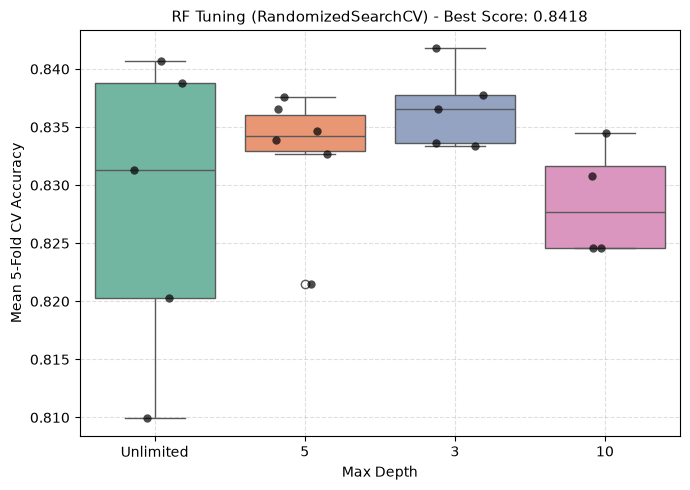

In [17]:
# Plotting the cross-validated accuracy scores for different max_depth values in Random Forest

# Prepare the results DataFrame for visualization
results_df = pd.DataFrame(rs_rf.cv_results_)
results_df["max_depth"] = (results_df["param_max_depth"].fillna("Unlimited").astype(str))

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=results_df,
    x="max_depth",
    y="mean_test_score",
    hue="max_depth",
    palette="Set2",
    legend=False, 
)
sns.stripplot(
    data=results_df,
    x="max_depth",
    y="mean_test_score",
    color="black",
    alpha=0.7,
    jitter=0.2,
    size=6,
)

best_score = rs_rf.best_score_
plt.title(f"RF Tuning (RandomizedSearchCV) - Best Score: {best_score:.4f}",fontsize=11,)
plt.xlabel("Max Depth")
plt.ylabel("Mean 5-Fold CV Accuracy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(tuning_plots_dir / "04_rf_hyperparameter_tuning.png", dpi=300)
plt.show()

# Evaluation of Tuned Model on Test Set

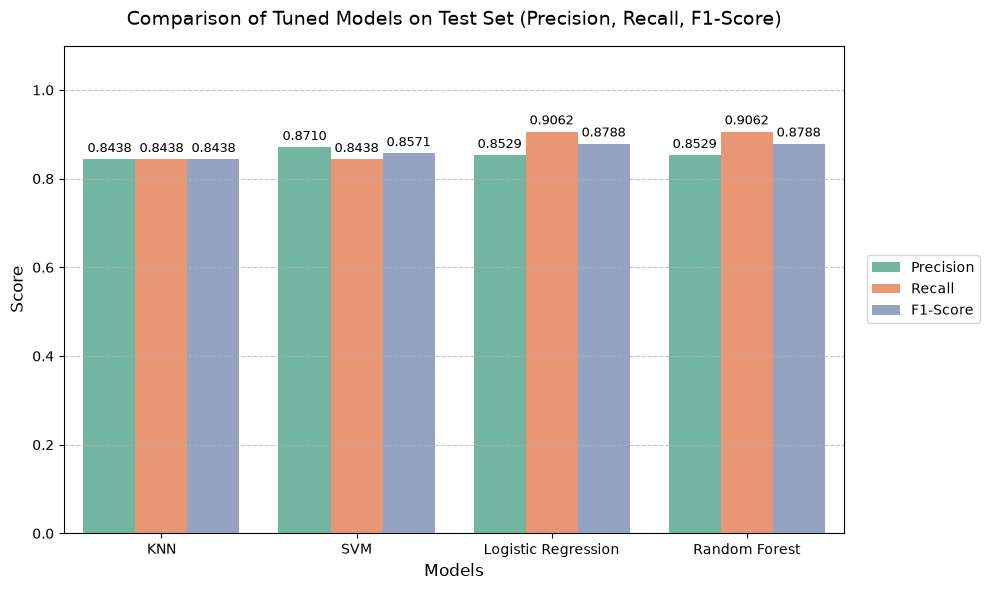

In [18]:
# Comparing Precision, Recall, and F1-Score for the Top 4 Tuned Models

models = {
    'KNN': gs_knn.best_estimator_,
    'SVM': gs_svm.best_estimator_,
    'Logistic Regression': gs_log_reg.best_estimator_,
    'Random Forest': rs_rf.best_estimator_,
}

# calculate Precision, Recall, and F1-Score for each model on the test set
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# Melt the results DataFrame for easier plotting
df_results = pd.DataFrame(results)
df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot using Seaborn's barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2')


plt.title('Comparison of Tuned Models on Test Set (Precision, Recall, F1-Score)', fontsize=14, pad=15)
plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# add legend at the center right outside the plot
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left')

# Add value labels on top of the bars (formatted to 2 decimal places)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig(evaluation_plots_dir / "01_precision_recall_f1_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

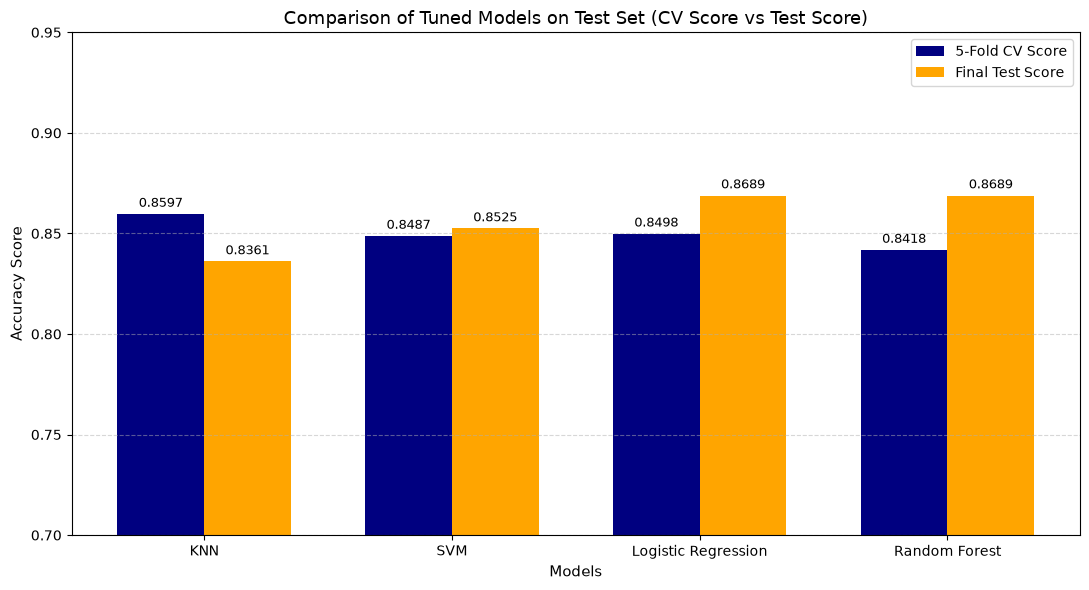

In [19]:
# Accuracy Comparison (Train vs Test Across 4 Models)

# Organize the results into a DataFrame for easier visualization
results_summary = pd.DataFrame({
    "Model": ["KNN", "SVM", "Logistic Regression", "Random Forest"],
    "5-Fold CV Score": [
        gs_knn.best_score_,
        gs_svm.best_score_,
        gs_log_reg.best_score_,
        rs_rf.best_score_
    ],
    "Final Test Score": [
        gs_knn.best_estimator_.score(X_test, y_test),
        gs_svm.best_estimator_.score(X_test, y_test),
        gs_log_reg.best_estimator_.score(X_test, y_test),
        rs_rf.best_estimator_.score(X_test, y_test)
    ]
})

# Plotting the comparison of CV scores and Test scores for the tuned models
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(results_summary))
width = 0.35

rects1 = ax.bar(x - width/2, results_summary["5-Fold CV Score"], width, label='5-Fold CV Score', color='navy')
rects2 = ax.bar(x + width/2, results_summary["Final Test Score"], width, label='Final Test Score', color='orange')

# Add value labels on top of the bars (formatted to 4 decimal places)
ax.bar_label(rects1, padding=3, fmt='%.4f', fontsize=9)
ax.bar_label(rects2, padding=3, fmt='%.4f', fontsize=9)

ax.set_xlabel('Models', fontsize=11,)
ax.set_ylabel('Accuracy Score', fontsize=11)
ax.set_title('Comparison of Tuned Models on Test Set (CV Score vs Test Score)', fontsize=13,)
ax.set_xticks(x)
ax.set_xticklabels(results_summary["Model"], fontsize=10)
ax.set_ylim(0.70, 0.95) 
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(evaluation_plots_dir / "02_accuracy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

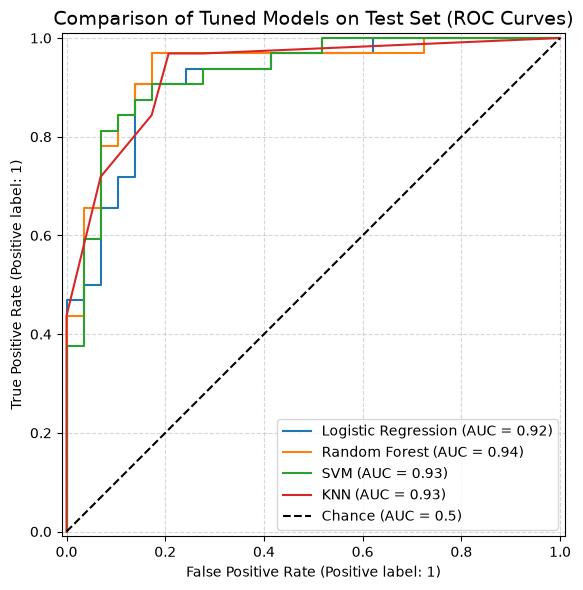

In [20]:
#  ROC / AUC Curves for all tuned models

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(gs_log_reg.best_estimator_, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rs_rf.best_estimator_, X_test, y_test, ax=ax, name="Random Forest")
RocCurveDisplay.from_estimator(gs_svm.best_estimator_, X_test, y_test, ax=ax, name="SVM")
RocCurveDisplay.from_estimator(gs_knn.best_estimator_, X_test, y_test, ax=ax, name="KNN")  

plt.plot([0, 1], [0, 1], 'k--', label="Chance (AUC = 0.5)")
plt.title("Comparison of Tuned Models on Test Set (ROC Curves)", fontsize=14)
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(evaluation_plots_dir / "03_roc_curves_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

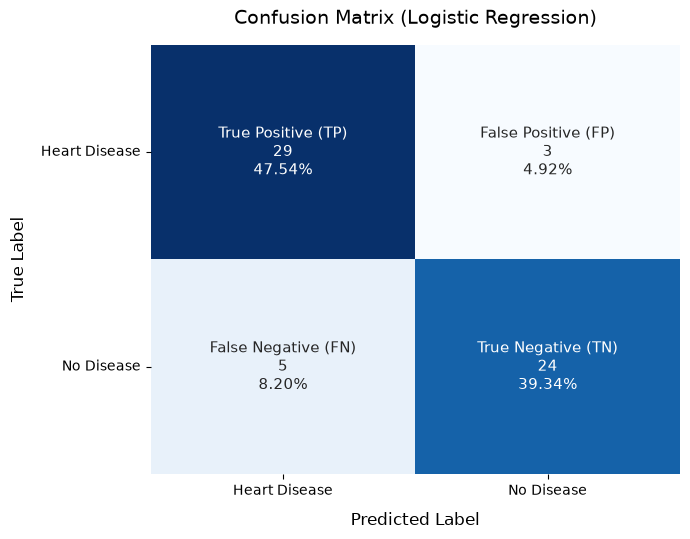

In [21]:
# Confusion Matrix Visualization Function

def plot_pretty_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix with labels (TP, FP, TN, FN)
    and dual annotation (count and percentage).
    """  
    # Positive class (1) is "Heart Disease", Negative class (0) is "No Disease"
    cm = confusion_matrix(y_test, y_preds, labels=[1, 0])    
    # Calculate group names, counts, and percentages
    group_names = ["True Positive (TP)", "False Positive (FP)",
                   "False Negative (FN)", "True Negative (TN)"]
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]   
    # Combine the labels into a single array for annotation
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)    
    # Plotting the confusion matrix with annotations
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Heart Disease", "No Disease"],
                yticklabels=["Heart Disease", "No Disease"],
                annot_kws={"fontsize": 11})
    plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
    plt.ylabel("True Label", fontsize=12, labelpad=10)
    plt.title("Confusion Matrix (Logistic Regression)", fontsize=14, pad=15)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(evaluation_plots_dir / "04_confusion_matrix_detailed.png", dpi=300, bbox_inches='tight')
    plt.show()

# Take the best model (Logistic Regression) and make predictions on the test set
best_model = gs_log_reg.best_estimator_
y_preds = best_model.predict(X_test)

plot_pretty_conf_mat(y_test, y_preds)

# Feature Importance

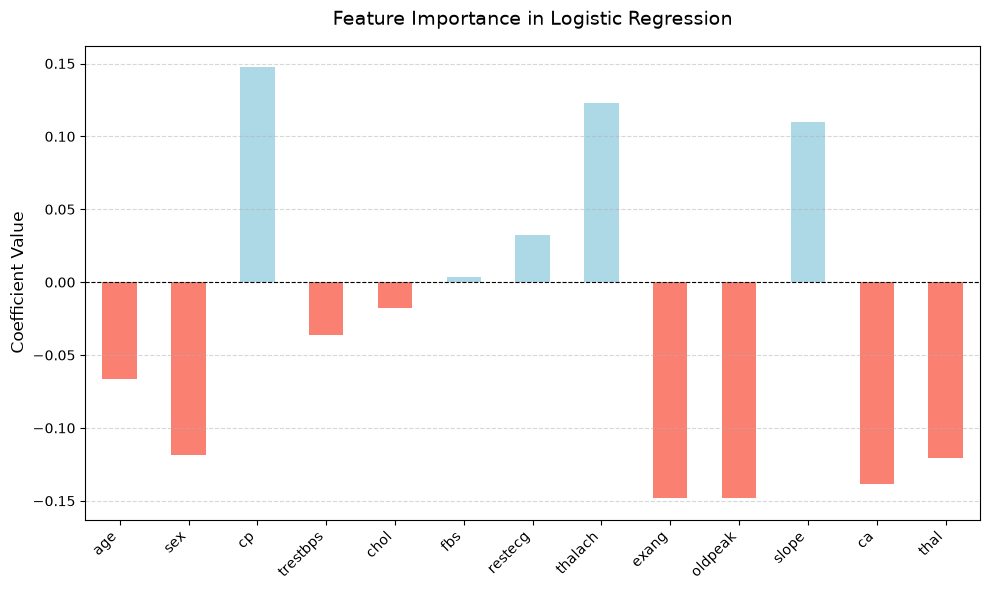

In [22]:
# Feature Importance Visualization for Logistic Regression

clf = gs_log_reg.best_estimator_.named_steps["model"]

# Create a dictionary mapping feature names to their corresponding coefficients
feature_dict = dict(zip(X_train.columns, list(clf.coef_[0])))
feature_df = pd.DataFrame(feature_dict, index=[0]).T
feature_df.columns = ["Coefficient"]

# Plotting the feature importance as a bar chart
colors = ["salmon" if x < 0 else "lightblue" for x in feature_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(10, 6))
feature_df["Coefficient"].plot(kind="bar", color=colors, ax=ax)

plt.title("Feature Importance in Logistic Regression", fontsize=14, pad=15)
plt.ylabel("Coefficient Value", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(features_plots_dir / "01_feature_importance_log_reg.png", dpi=300, bbox_inches='tight')
plt.show()


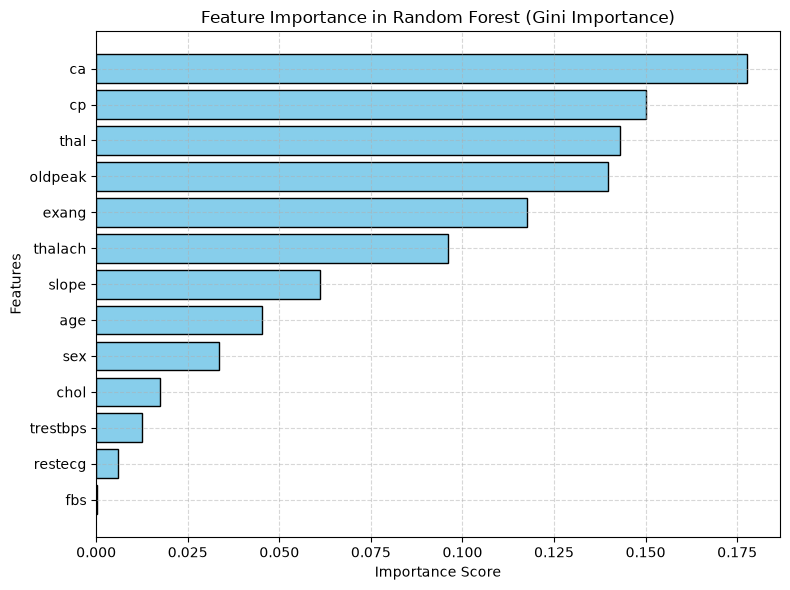

In [23]:
# Feature Importance Visualization for Random Forest Classifier

importances = rs_rf.best_estimator_.feature_importances_

# Sort the features by importance

feature_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

# plot the feature importances as a horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(feature_imp_df["Feature"], feature_imp_df["Importance"], color="skyblue", edgecolor="black")

plt.title("Feature Importance in Random Forest (Gini Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig(features_plots_dir / "02_feature_importance_random_forest.png", dpi=300, bbox_inches='tight')
plt.show()

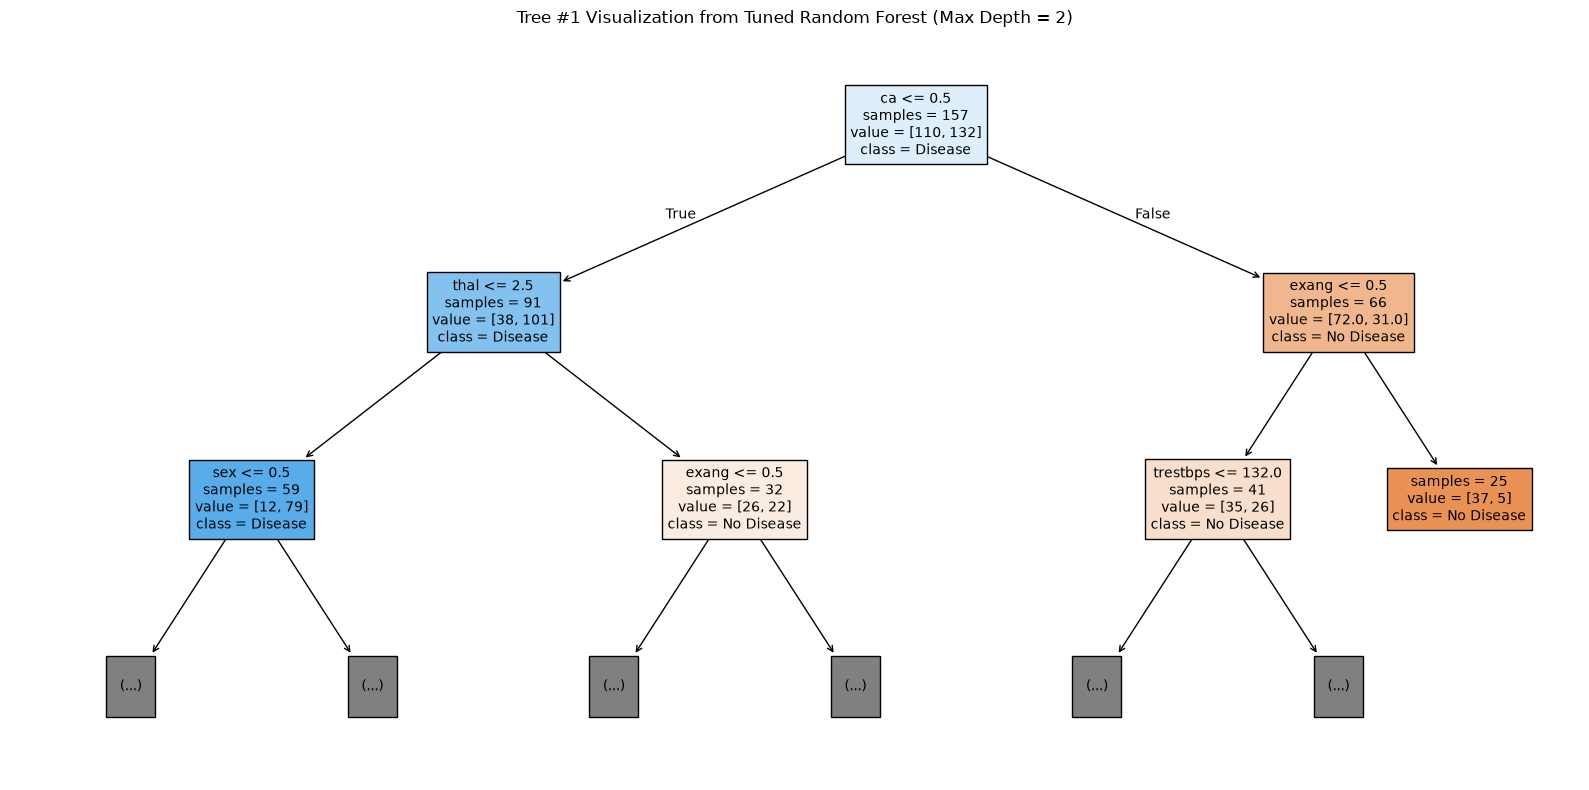

In [24]:
# Visualizing the first tree of the best Random Forest model

plt.figure(figsize=(16, 8))
plot_tree(
    rs_rf.best_estimator_.estimators_[0], 
    feature_names=X_train.columns,
    class_names=["No Disease", "Disease"],
    filled=True, 
    max_depth=2,
    fontsize=10,
    impurity=False
)
plt.title("Tree #1 Visualization from Tuned Random Forest (Max Depth = 2)")
plt.tight_layout()
plt.savefig( features_plots_dir / "03_random_forest_tree_visualization.png", dpi=300, bbox_inches='tight')
plt.show()